# VERİ SETİ ÖN İŞLEME VE DİZİ SAYISALLAŞTIRMA
#### AÇIKLAMA: 
- Yaklaşık 500 ve üzeri protein çeşitliliği içeren insan vucuduna ait Kinaz ve GPCR protein ailelerinden her bir protein  ailesinden basit rastgele örnekleme yöntemiyle (Simple Random Sampling) Train için 200 er örnek (Train toplam: 400) ve test için 100 er örnek (Test toplam: 200) Uniprot ve NCBI gen bankasından indirilerek ön işleme yapılıp 300aa ve 900 nt uzunluklu diziler şeklinde kaydedilmişti.
- Çalışanın bu aşamasında, fasta formunda indirilen bu diziler CDS-DNA, KODON ve AMİNOASİT dizi formu için önerilen kompleks değerli yöntemler kullanılarak sayısallaştırılmaktadır (kodlanmaktadır).
- Çalışmada karşılaştırmada kullanılmak üzere aynı veri seti literatürde mevcut reel değerli yöntemler kullanılarak tam sayılara kodlanmaktadır/sayısallaştırılmaktadır.
- Urasil-Timin  (U=T) denkliği çalışmada esastır


## AŞAMALAR:

### 1) CDS-DNA DİZİLERİNİN KODLANMASI (Kompleks & Reel)
- a. CDS-DNA ham fasta dizilerinin etiketlenip uzunlukların eşitlenmesi ve rastgele karılması.
- b. CDS-DNA dizilerinin önerilen yöntemle KOMPLEKS SAYILARA kodlanması
- c. CDS-DNA dizilerinin karşılaştırma için mevcut yöntemle REEL DEĞERLİ Tam sayılara kodlanması

### 2) KODON FORMUNDA DİZİLERİNİN KODLANMASI (Kompleks & Reel)
- a. CDS-DNA dizilerinin KODON formunda önerilen yöntemle KOMPLEKS SAYILARA  kodlanması
- b. CDS-DNA dizilerinin KODON formunda mevcut yöntemle REEL SAYILARA  kodlanması

### 3) AMİNOASİT DİZİLERİNİN KODLANMASI (Kompleks & Reel)
- a. AMİNOASİT ham fasta dizilerinin etiketlenip uzunlukların eşitlenmesi ve rastgele karılması.
- b. AMİNOASİT dizilerinin önerilen yöntemle KOMPLEKS SAYILARA  kodlanması
- c. AMİNOASİT dizilerinin karşılaştırma için mevcut yöntemle REEL DEĞERLİ Tam sayılara kodlanması


## 1) CDS-DNA DİZİLERİNİN KODLANMASI
#### a. CDS-DNA fasta dizilerinin etiketlenip uzunlukların eşitlenmesi ve rastgele karılması.

In [1]:
"""
=======================================================================
ADIM 1 - CDS-DNA DIZILERININ ETIKETLENMESI, UZUNLUK ESITLEMESI VE
                         RASTGELE KARILMASI  
======================================================================

"""

from pathlib import Path
import datetime
import re

import pandas as pd

# ======================================================================
# AYARLAR
# ======================================================================
GIRDI_XLSX = "3_veri_seti.xlsx"
LOG_DOSYA  = "boru_hatti.log"
SAYFALAR   = ["EGITIM", "TEST"]
TOHUM      = 42

# --- Sabit girdi uzunlugu (nt) ---------------------------------
# 900 nt = 300 kodon = 300 aa. 
HEDEF_UZUNLUK_NT = 900

# --- Sonlandrıcı kodon ------------------------------------------------
 
SONLANDIRICI_AT = True
SONLANDIRICILAR = {"TAA", "TAG", "TGA"}

# --- Kırpma  -------------------------------------------------
KIRPMA_YONU    = "bas"    # 
CERCEVEYI_KORU = True     # kırpma baslangıcını 3'un katı 

# --- Kısa kayıt  ----------------------------------------------

KISA_KAYIT = "hata"

ETIKET = {"GPCR": 0, "KINASE": 1}
GECERLI_BAZLAR = set("ACGT")
CIKTI_XLSX = f"cds_DNA_fasta_hazır_L900.xlsx"


# ======================================================================
# Yardımcı fonksyonlar
# ======================================================================
def log_yaz(satir: str) -> None:
    damga = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with open(LOG_DOSYA, "a", encoding="utf-8") as f:
        f.write(f"[{damga}] adim4a | {satir}\n")


def diziyi_temizle(x) -> str:

    if x is None:
        return ""
    s = str(x).strip()
    if s.lower() in ("", "nan", "none", "null"):
        return ""
    if s.startswith(">"):
        s = "".join(s.splitlines()[1:])
    return re.sub(r"\s+", "", s).upper()


def sonlandiriciyi_kaldir(seq: str):
    if len(seq) >= 3 and seq[-3:] in SONLANDIRICILAR:
        return seq[:-3], True
    return seq, False


def kirp(seq: str, L: int) -> str:

    n = len(seq)
    if KIRPMA_YONU == "bas":
        bas = 0
    elif KIRPMA_YONU == "son":
        bas = n - L
    else:
        bas = (n - L) // 2
    if CERCEVEYI_KORU:
        bas -= bas % 3
    return seq[bas:bas + L]


# ======================================================================
# Sayfa işle
# ======================================================================
def sayfayi_isle(sheet: str) -> pd.DataFrame:
    df = pd.read_excel(GIRDI_XLSX, sheet_name=sheet)

    for c in ("cds_dna", "label", "Uniprot_Accession"):
        if c not in df.columns:
            raise ValueError(f"'{sheet}' sayfasinda '{c}' kolonu yok.")

    df = df.copy()
    df["dna_ham"] = df["cds_dna"].apply(diziyi_temizle)

    # --- dogrulamalar --------------------------------------------------
    bos = int((df["dna_ham"] == "").sum())
    if bos:
        log_yaz(f"{sheet}: bos cds_dna nedeniyle {bos} kayit atildi.")
        df = df[df["dna_ham"] != ""].copy()

    gecersiz = df["dna_ham"].apply(lambda s: bool(set(s) - GECERLI_BAZLAR))
    if gecersiz.any():
        log_yaz(f"{sheet}: ACGT disi harf iceren {int(gecersiz.sum())} kayit atildi.")
        df = df[~gecersiz].copy()

    cerceve = df["dna_ham"].str.len() % 3 != 0
    if cerceve.any():
        log_yaz(f"{sheet}: uzunlugu 3'un kati olmayan {int(cerceve.sum())} kayit atildi.")
        df = df[~cerceve].copy()

    # --- son kodon --------------------------------------------
    if SONLANDIRICI_AT:
        sonuc = df["dna_ham"].apply(sonlandiriciyi_kaldir)
        df["dna_ham"] = sonuc.apply(lambda t: t[0])
        atilan = int(sonuc.apply(lambda t: t[1]).sum())
        log_yaz(f"{sheet}: {atilan}/{len(df)} kayitta sonlandirici kodon atildi.")

    df["ham_uzunluk"] = df["dna_ham"].str.len()   

    # --- dolgudenetimi ----------------------------------------
    kisa = df["ham_uzunluk"] < HEDEF_UZUNLUK_NT
    if kisa.any():
        liste = df.loc[kisa, "Uniprot_Accession"].tolist()
        mesaj = (f"{sheet}: {int(kisa.sum())} kayit {HEDEF_UZUNLUK_NT} nt'den kisa "
                 f"-> {liste[:10]}")
        log_yaz(mesaj)
        if KISA_KAYIT == "hata":
            raise ValueError(mesaj + "  | Dolgu kapali. L'yi dusurun ya da "
                                     "KISA_KAYIT='at' yapin.")
        df = df[~kisa].copy()

    # --- kırpma ---------------------------------------------------------
    df[f"dna_seq_{HEDEF_UZUNLUK_NT}"] = df["dna_ham"].apply(
        lambda s: kirp(s, HEDEF_UZUNLUK_NT))
    df["kirpilan_nt"] = df["ham_uzunluk"] - HEDEF_UZUNLUK_NT

    # --- etiket ----------------------------------------------------------
    bilinmeyen = set(df["label"].unique()) - set(ETIKET)
    if bilinmeyen:
        raise ValueError(f"'{sheet}' sayfasinda taninmayan etiket: {bilinmeyen}")
    df["y"] = df["label"].map(ETIKET).astype(int)

    # --- rastgele karma --------------------------------------------------
    df = df.sample(frac=1.0, random_state=TOHUM).reset_index(drop=True)
    return df


def ciktiyi_duzenle(df: pd.DataFrame) -> pd.DataFrame:
    kolonlar = [
        "Uniprot_Accession", "Entry_ID", "Gene_Name", "Protein_Name",
        "label", "y", "alt_sinif", "split",
        "Length", "cds_len", "ham_uzunluk", "kirpilan_nt",
        "secilen_NP", "secilen_NM",
        f"dna_seq_{HEDEF_UZUNLUK_NT}",
    ]
    return df[[c for c in kolonlar if c in df.columns]]


# ======================================================================
# Calıştır
# ======================================================================
def main() -> None:
    if not Path(GIRDI_XLSX).exists():
        raise FileNotFoundError(f"{GIRDI_XLSX} bulunamadi.")

    log_yaz(f"BASLANGIC | L={HEDEF_UZUNLUK_NT} nt (dolgusuz) | "
            f"sonlandirici_at={SONLANDIRICI_AT} | kirpma={KIRPMA_YONU} | tohum={TOHUM}")

    tablolar = {s: sayfayi_isle(s) for s in SAYFALAR}

    with pd.ExcelWriter(CIKTI_XLSX, engine="openpyxl") as w:
        for s, df in tablolar.items():
            ciktiyi_duzenle(df).to_excel(w, sheet_name=s, index=False)

    print(f"Bitti. Cikti: {CIKTI_XLSX}  (L = {HEDEF_UZUNLUK_NT} nt, dolgu yok)")
    for s, df in tablolar.items():
        seq_kol = f"dna_seq_{HEDEF_UZUNLUK_NT}"
        assert (df[seq_kol].str.len() == HEDEF_UZUNLUK_NT).all()
        ozet = (f"{s}: n={len(df)} | {df['label'].value_counts().to_dict()} | "
                f"tum diziler {HEDEF_UZUNLUK_NT} nt | dolgulu kayit=0 | "
                f"ort_kirpilan={df['kirpilan_nt'].mean():.0f} nt")
        print("  " + ozet)
        log_yaz(ozet)
        for sinif, alt in df.groupby("label"):
            satir = (f"{s}/{sinif}: n={len(alt)} | ham ortanca="
                     f"{alt['ham_uzunluk'].median():.0f} nt | "
                     f"ort_kirpilan={alt['kirpilan_nt'].mean():.0f} nt")
            print("    " + satir)
            log_yaz(satir)

    log_yaz("BITIS")


if __name__ == "__main__":
    main()

Bitti. Cikti: cds_DNA_fasta_hazır_L900.xlsx  (L = 900 nt, dolgu yok)
  EGITIM: n=400 | {'KINASE': 200, 'GPCR': 200} | tum diziler 900 nt | dolgulu kayit=0 | ort_kirpilan=752 nt
    EGITIM/GPCR: n=200 | ham ortanca=984 nt | ort_kirpilan=289 nt
    EGITIM/KINASE: n=200 | ham ortanca=1858 nt | ort_kirpilan=1215 nt
  TEST: n=200 | {'GPCR': 100, 'KINASE': 100} | tum diziler 900 nt | dolgulu kayit=0 | ort_kirpilan=811 nt
    TEST/GPCR: n=100 | ham ortanca=1010 nt | ort_kirpilan=364 nt
    TEST/KINASE: n=100 | ham ortanca=1940 nt | ort_kirpilan=1259 nt


In [4]:
"""
======================================================================
4a CIKTISININ ILK 5 SATIRININ YAZDIRILMASI (ERISIM NO, DIZI, LABEL/y)
======================================================================
"""
import pandas as pd

HEDEF_UZUNLUK_NT = 900
DNA_XLSX = f"cds_DNA_fasta_hazır_L900.xlsx"
SEQ_KOL = f"dna_seq_{HEDEF_UZUNLUK_NT}"
PREVIEW_LEN = 30   


def preview(seq, n=30) -> str:
    
    s = str(seq)
    return s[:n] + "..." if len(s) > n else s


xls = pd.ExcelFile(DNA_XLSX)
for sheet in xls.sheet_names:
    df = pd.read_excel(DNA_XLSX, sheet_name=sheet)
    needed = ["Uniprot_Accession", "label", "y", SEQ_KOL]
    if not all(c in df.columns for c in needed):
        print(f"\n[{sheet}] -> kolon eksik, atlandi.")
        continue

    df["dna_preview"] = df[SEQ_KOL].apply(lambda x: preview(x, PREVIEW_LEN))

    goster = ["Uniprot_Accession", "dna_preview", "label", "y"]

    print("\n" + "=" * 80)
    print(f"[{sheet}] ILK 5 SATIR  (erisim no | dizi ilk {PREVIEW_LEN} baz | label | y)")
    print("=" * 80)
    print(df[goster].head(5).to_string(index=False))


[EGITIM] ILK 5 SATIR  (erisim no | dizi ilk 30 baz | label | y)
Uniprot_Accession                       dna_preview  label  y
           O96017 ATGTCTCGGGAGTCGGATGTTGAGGCTCAG... KINASE  1
           P41240 ATGTCAGCAATACAGGCCGCCTGGCCATCC... KINASE  1
           Q01726 ATGGCTGTGCAGGGATCCCAGAGAAGACTT...   GPCR  0
           Q5MAI5 ATGGAAAAGTATGAAAAATTAGCTAAGACT... KINASE  1
           Q8NH57 ATGGAATCTCCTAATCACACTGATGTTGAC...   GPCR  0

[TEST] ILK 5 SATIR  (erisim no | dizi ilk 30 baz | label | y)
Uniprot_Accession                       dna_preview  label  y
           O60403 ATGCTGGGGCTAAACCACACCTCCATGTCT...   GPCR  0
           Q9H341 ATGTCAGTCCAATATTCGCTCAGTCCTCAA...   GPCR  0
           Q13606 ATGGAATTTACAGATAGAAACTACACGTTG...   GPCR  0
           P43403 ATGCCAGACCCCGCGGCGCACCTGCCCTTC... KINASE  1
           P49336 ATGGACTATGACTTTAAAGTGAAGCTGAGC... KINASE  1


#### b. CDS-DNA dizilerinin önerilen yöntemle KOMPLEKS SAYILARA kodlanması


In [8]:
"""
=======================================================================
ADIM 2 - CDS-DNA DIZILERININ ONERILEN YONTEMLE KOMPLEKS SAYILARA
          KODLANMASI      (L = 900 nt, 
Not: kayıt için .npz dosya kullanıldı. fasta dizileri excel de mevcut.
=======================================================================
"""

from pathlib import Path
import datetime

import numpy as np
import pandas as pd

# ======================================================================
# AYARLAR
# ======================================================================

HEDEF_UZUNLUK_NT = 900           
GIRDI_XLSX = f"cds_DNA_fasta_hazır_L900.xlsx"
CIKTI_NPZ  = f"cds_DNA_Compleks_L900.npz"
CIKTI_XLSX = f"cds_DNA_Compleks_L900_Özet.xlsx"
LOG_DOSYA  = "boru_hatti.log"
SAYFALAR   = ["EGITIM", "TEST"]

# --- Kompleks  yontem--------------------------------
ESLEME = {"A": 1j, "T": -1j, "G": 1 + 0j, "C": -1 + 0j}

# --- Konum  ----------------------------------------------------

AGIRLIK = "konum"


OLCEKLEME = "yok"

# Real/Imag/Mod/Faz duzlemlerini de npz'ye yaz 
OZELLIK_DUZLEMLERI = True


# ======================================================================
# Yardimcilar
# ======================================================================
def log_yaz(satir: str) -> None:
    damga = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with open(LOG_DOSYA, "a", encoding="utf-8") as f:
        f.write(f"[{damga}] adim4b | {satir}\n")


def agirlik_vektoru(L: int) -> np.ndarray:
    if AGIRLIK == "konum":
        a = np.arange(1, L + 1, dtype=np.float64)
    elif AGIRLIK == "yok":
        a = np.ones(L, dtype=np.float64)
    else:
        raise ValueError("AGIRLIK 'konum' veya 'yok' olmalidir.")
    if OLCEKLEME == "bol_L":
        a = a / L
    elif OLCEKLEME != "yok":
        raise ValueError("OLCEKLEME 'yok' veya 'bol_L' olmalidir.")
    return a


def diziyi_kodla(dizi: str, a: np.ndarray) -> np.ndarray:
    taban = np.fromiter((ESLEME[b] for b in dizi),
                        dtype=np.complex128, count=len(dizi))
    return (a * taban).astype(np.complex64)


def sayfayi_kodla(sheet: str):
    df = pd.read_excel(GIRDI_XLSX, sheet_name=sheet)
    seq_kol = f"dna_seq_{HEDEF_UZUNLUK_NT}"
    if seq_kol not in df.columns:
        raise ValueError(f"'{sheet}' sayfasinda '{seq_kol}' kolonu yok. "
                         f"4a betigini ayni L ile calistirin.")

    diziler = df[seq_kol].astype(str).tolist()
    uzunluklar = {len(s) for s in diziler}
    if uzunluklar != {HEDEF_UZUNLUK_NT}:
        raise ValueError(f"'{sheet}': tum diziler {HEDEF_UZUNLUK_NT} nt olmalidir, "
                         f"bulunan: {sorted(uzunluklar)}")

    gecersiz = {b for s in diziler for b in set(s)} - set(ESLEME)
    if gecersiz:
        raise ValueError(f"'{sheet}': eslemede olmayan karakter(ler): {gecersiz}")

    a = agirlik_vektoru(HEDEF_UZUNLUK_NT)
    X = np.stack([diziyi_kodla(s, a) for s in diziler]).astype(np.complex64)

    # dolgusuz kodlamada hicbir konum sifir olamaz
    if np.any(X == 0):
        raise AssertionError(f"'{sheet}': sifir deger bulundu (dolgu bekleniyor degildi).")

    return df, X


def ozellik_duzlemleri(X: np.ndarray):
    return (X.real.astype(np.float32),
            X.imag.astype(np.float32),
            np.abs(X).astype(np.float32),
            np.degrees(np.angle(X)).astype(np.float32))


# ======================================================================
# Calistir
# ======================================================================
def main() -> None:
    if not Path(GIRDI_XLSX).exists():
        raise FileNotFoundError(f"{GIRDI_XLSX} bulunamadi.")

    log_yaz(f"BASLANGIC | L={HEDEF_UZUNLUK_NT} (dolgusuz) | agirlik={AGIRLIK} "
            f"| olcekleme={OLCEKLEME}")

    paket, ozetler = {}, {}

    for sheet in SAYFALAR:
        df, X = sayfayi_kodla(sheet)
        onek = sheet.lower()

        paket[f"X_{onek}"] = X
        paket[f"y_{onek}"] = df["y"].to_numpy(dtype=np.int8)
        paket[f"acc_{onek}"] = np.array(
            df["Uniprot_Accession"].astype(str).tolist(), dtype="U32")

        if OZELLIK_DUZLEMLERI:
            reel, imag, mod, faz = ozellik_duzlemleri(X)
            paket[f"reel_{onek}"] = reel
            paket[f"imag_{onek}"] = imag
            paket[f"mod_{onek}"] = mod
            paket[f"faz_{onek}"] = faz

        ozet = df[[c for c in ("Uniprot_Accession", "Gene_Name", "label", "y",
                               "alt_sinif", "ham_uzunluk", "kirpilan_nt")
                   if c in df.columns]].copy()
        ozet["ilk5_kompleks"] = [
            "; ".join(f"{z.real:.5f}{z.imag:+.5f}j" for z in satir[:5]) for satir in X
        ]
        ozetler[sheet] = ozet

        satir = (f"{sheet}: X={X.shape} dtype={X.dtype} | "
                 f"ort|z|={float(np.abs(X).mean()):.5f} | dolgu=yok")
        print("  " + satir)
        log_yaz(satir)

    paket["L"] = np.array([HEDEF_UZUNLUK_NT])
    paket["etiket_sozlugu"] = np.array(["GPCR=0", "KINASE=1"])
    paket["kodlama"] = np.array([f"A=+j,T=-j,G=+1,C=-1; agirlik={AGIRLIK}; "
                                 f"olcekleme={OLCEKLEME}; dolgu=yok"])

    np.savez_compressed(CIKTI_NPZ, **paket)
    with pd.ExcelWriter(CIKTI_XLSX, engine="openpyxl") as w:
        for sheet, ozet in ozetler.items():
            ozet.to_excel(w, sheet_name=sheet, index=False)

    print(f"Bitti. Cikti: {CIKTI_NPZ}  ve  {CIKTI_XLSX}")
    log_yaz("BITIS")


# ----------------------------------------------------------------------
# Kullanim

# ----------------------------------------------------------------------

if __name__ == "__main__":
    main()

  EGITIM: X=(400, 900) dtype=complex64 | ort|z|=450.50000 | dolgu=yok
  TEST: X=(200, 900) dtype=complex64 | ort|z|=450.50000 | dolgu=yok
Bitti. Cikti: cds_DNA_Compleks_L900.npz  ve  cds_DNA_Compleks_L900_Özet.xlsx


In [9]:
"""
======================================================================
 CIKTISININ ILK 5 SATIRININ OKUNMASI VE YAZDIRILMASI
======================================================================

"""
from pathlib import Path
import numpy as np
import pandas as pd

HEDEF_UZUNLUK_NT = 900
NPZ  = f"cds_DNA_Compleks_L900.npz"
XLSX = f"cds_DNA_Compleks_L900_Özet.xlsx"
N = 5          
K = 5         
SAYFALAR = ["egitim", "test"]


def kompleks_yaz(z_satiri, k=5) -> str:
    return "; ".join(f"{z.real:+.5f}{z.imag:+.5f}j" for z in z_satiri[:k]) + " ..."


# ---------------------------------------------------------------------
# 1) NPZ - asıl veri
# ---------------------------------------------------------------------
d = np.load(NPZ, allow_pickle=False)

print("=" * 80)
print(f"NPZ: {NPZ}")
print("Kayitli diziler:", ", ".join(sorted(d.files)))
print("L =", int(d["L"][0]), "| kodlama:", str(d["kodlama"][0]))
print("=" * 80)

for onek in SAYFALAR:
    X   = d[f"X_{onek}"]        
    y   = d[f"y_{onek}"]        
    acc = d[f"acc_{onek}"]      
    print(f"\n[{onek.upper()}]  X={X.shape} {X.dtype} | y={y.shape} | "
          f"ilk {N} kayit (ilk {K} kompleks deger)")
    print("-" * 80)
    for i in range(min(N, len(X))):
        etiket = "GPCR" if y[i] == 0 else "KINASE"
        print(f"{acc[i]:<10} y={y[i]} ({etiket:<6}) | {kompleks_yaz(X[i], K)}")


# ---------------------------------------------------------------------
# 2) OZET XLSX - ustveri
# ---------------------------------------------------------------------
if Path(XLSX).exists():
    print("\n" + "=" * 80)
    print(f"OZET XLSX: {XLSX}")
    print("=" * 80)
    xls = pd.ExcelFile(XLSX)
    for sheet in xls.sheet_names:
        df = pd.read_excel(XLSX, sheet_name=sheet)
        print(f"\n[{sheet}] ilk {N} satir  (kolonlar: {list(df.columns)})")
        print("-" * 80)
        print(df.head(N).to_string(index=False))

NPZ: cds_DNA_Compleks_L900.npz
Kayitli diziler: L, X_egitim, X_test, acc_egitim, acc_test, etiket_sozlugu, faz_egitim, faz_test, imag_egitim, imag_test, kodlama, mod_egitim, mod_test, reel_egitim, reel_test, y_egitim, y_test
L = 900 | kodlama: A=+j,T=-j,G=+1,C=-1; agirlik=konum; olcekleme=yok; dolgu=yok

[EGITIM]  X=(400, 900) complex64 | y=(400,) | ilk 5 kayit (ilk 5 kompleks deger)
--------------------------------------------------------------------------------
O96017     y=1 (KINASE) | +0.00000+1.00000j; +0.00000-2.00000j; +3.00000+0.00000j; +0.00000-4.00000j; -5.00000+0.00000j ...
P41240     y=1 (KINASE) | +0.00000+1.00000j; +0.00000-2.00000j; +3.00000+0.00000j; +0.00000-4.00000j; -5.00000+0.00000j ...
Q01726     y=0 (GPCR  ) | +0.00000+1.00000j; +0.00000-2.00000j; +3.00000+0.00000j; +4.00000+0.00000j; -5.00000+0.00000j ...
Q5MAI5     y=1 (KINASE) | +0.00000+1.00000j; +0.00000-2.00000j; +3.00000+0.00000j; +4.00000+0.00000j; +0.00000+5.00000j ...
Q8NH57     y=0 (GPCR  ) | +0.00000+1

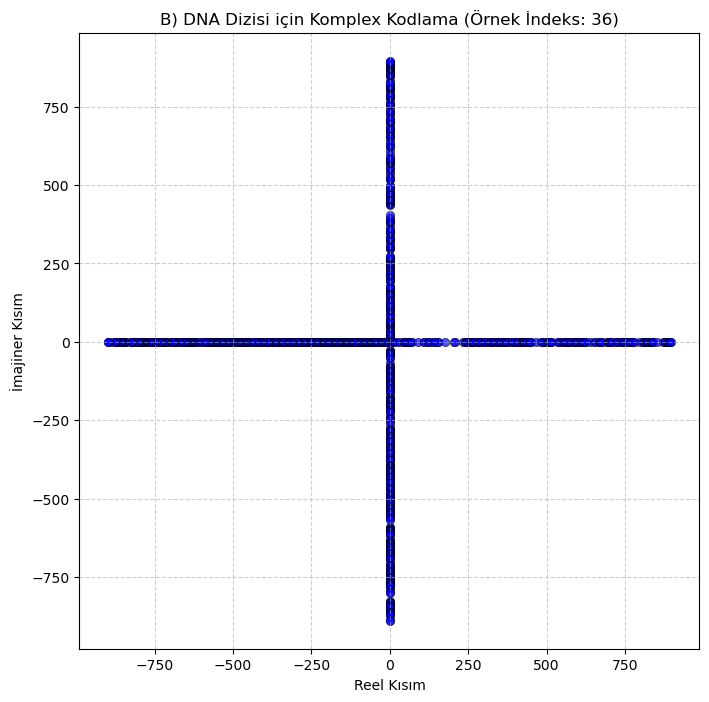

In [2]:
"""
======================================================================
DNA Dizisi için Komplex Kodlanan dosaydan bir örnek
======================================================================

"""

import matplotlib.pyplot as plt
import numpy as np

# 1. .npz dosyasının yolu
npz_file_path = "cds_DNA_Compleks_L900.npz"  # Dosya yolu
data = np.load(npz_file_path)

# 2. .npz içerisindeki ilk anahtar veri dizisini al
array_key = data.files[0]
complex_matrix = data[array_key]

# 3. Veri kümesindeki satırlardan (dizilerden) rastgele birini seç
random_idx = np.random.randint(0, complex_matrix.shape[0])
complex_numbers = complex_matrix[random_idx]

# 4. Reel ve İmajiner kısımları ayır
real_parts = complex_numbers.real
imaginary_parts = complex_numbers.imag

# 5. Grafiği oluştur
plt.figure(figsize=(8, 8))
plt.scatter(
    real_parts,
    imaginary_parts,
    color="blue",
    alpha=0.7,
    edgecolors="k",
    linewidth=0.5,
)

plt.xlabel("Reel Kısım")
plt.ylabel("İmajiner Kısım")
plt.title(f"B) DNA Dizisi için Komplex Kodlama (Örnek İndeks: {random_idx})")
plt.grid(True, linestyle="--", alpha=0.6)

# Yüksek kalitede kaydet 
plt.savefig("high_quality_plots.png", dpi=600, bbox_inches="tight")

plt.show()

#### c. CDS-DNA dizilerinin karşılaştırma için mevcut yöntemle REEL DEĞERLİ Tam sayılara kodlanması

In [11]:

"""
=======================================================================
ADIM 3 - CDS-DNA DIZILERININ KARSILASTIRMA ICIN LİT. de MEVCUT (REEL) YONTEMLE
          KODLANMASI      (L = 900 nt)
=======================================================================

"""

from pathlib import Path
import datetime

import numpy as np
import pandas as pd

# ======================================================================
# AYARLAR
# ======================================================================
HEDEF_UZUNLUK_NT = 900           
GIRDI_XLSX = f"cds_DNA_fasta_hazır_L900.xlsx"
CIKTI_NPZ  = f"cds_DNA_Reel_L900.npz"
CIKTI_XLSX = f"cds_DNA_Reel_L900_Özet.xlsx"
LOG_DOSYA  = "boru_hatti.log"
SAYFALAR   = ["EGITIM", "TEST"]

# --- Reel esleme (literaturdeki tam sayı yontemi) ---------------------
NUKLEOTIT = {"T": 0, "C": 1, "A": 2, "G": 3}

ONE_HOT_URET = False


# ======================================================================
# Yardımcılar
# ======================================================================
def log_yaz(satir: str) -> None:
    damga = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with open(LOG_DOSYA, "a", encoding="utf-8") as f:
        f.write(f"[{damga}] adim4c | {satir}\n")


def diziyi_kodla(dizi: str) -> np.ndarray:
    return np.fromiter((NUKLEOTIT[b] for b in dizi), dtype=np.int8, count=len(dizi))


def one_hot(X: np.ndarray) -> np.ndarray:
    """(n, L) tam sayi -> (n, L, 4) ikili."""
    n, L = X.shape
    O = np.zeros((n, L, 4), dtype=np.uint8)
    satir, sutun = np.indices((n, L))
    O[satir, sutun, X] = 1
    return O


def sayfayi_kodla(sheet: str):
    df = pd.read_excel(GIRDI_XLSX, sheet_name=sheet)
    seq_kol = f"dna_seq_{HEDEF_UZUNLUK_NT}"
    if seq_kol not in df.columns:
        raise ValueError(f"'{sheet}' sayfasinda '{seq_kol}' kolonu yok. "
                         f"4a betigini ayni L ile calistirin.")

    diziler = df[seq_kol].astype(str).tolist()
    uzunluklar = {len(s) for s in diziler}
    if uzunluklar != {HEDEF_UZUNLUK_NT}:
        raise ValueError(f"'{sheet}': tum diziler {HEDEF_UZUNLUK_NT} nt olmalidir, "
                         f"bulunan: {sorted(uzunluklar)}")

    gecersiz = {b for s in diziler for b in set(s)} - set(NUKLEOTIT)
    if gecersiz:
        raise ValueError(f"'{sheet}': eslemede olmayan karakter(ler): {gecersiz}")

    X = np.stack([diziyi_kodla(s) for s in diziler]).astype(np.int8)
    return df, X




# ======================================================================
# Calıştr
# ======================================================================
def main() -> None:
    if not Path(GIRDI_XLSX).exists():
        raise FileNotFoundError(f"{GIRDI_XLSX} bulunamadi. Once 4a betigini calistirin.")

    log_yaz(f"BASLANGIC | L={HEDEF_UZUNLUK_NT} (dolgusuz) | one_hot={ONE_HOT_URET}")

    paket, ozetler = {}, {}

    for sheet in SAYFALAR:
        df, X = sayfayi_kodla(sheet)
        onek = sheet.lower()

        paket[f"X_{onek}"] = X
        paket[f"y_{onek}"] = df["y"].to_numpy(dtype=np.int8)
        paket[f"acc_{onek}"] = np.array(
            df["Uniprot_Accession"].astype(str).tolist(), dtype="U32")
        if ONE_HOT_URET:
            paket[f"onehot_{onek}"] = one_hot(X)

        ozet = df[[c for c in ("Uniprot_Accession", "Gene_Name", "label", "y",
                               "alt_sinif", "ham_uzunluk", "kirpilan_nt")
                   if c in df.columns]].copy()
        ozet["ilk20_kod"] = ["".join(str(v) for v in satir[:20]) for satir in X]
        ozetler[sheet] = ozet

        satir = f"{sheet}: X={X.shape} dtype={X.dtype} | dolgu=yok"
        print("  " + satir)
        log_yaz(satir)

    paket["L"] = np.array([HEDEF_UZUNLUK_NT])
    paket["etiket_sozlugu"] = np.array(["GPCR=0", "KINASE=1"])
    paket["kodlama"] = np.array(["T=0,C=1,A=2,G=3; dolgu=yok"])

    hizalamayi_dogrula(paket)

    np.savez_compressed(CIKTI_NPZ, **paket)
    with pd.ExcelWriter(CIKTI_XLSX, engine="openpyxl") as w:
        for sheet, ozet in ozetler.items():
            ozet.to_excel(w, sheet_name=sheet, index=False)

    print(f"Bitti. Cikti: {CIKTI_NPZ}  ve  {CIKTI_XLSX}")
    log_yaz("BITIS")


if __name__ == "__main__":
    main()

  EGITIM: X=(400, 900) dtype=int8 | dolgu=yok
  TEST: X=(200, 900) dtype=int8 | dolgu=yok
Bitti. Cikti: cds_DNA_Reel_L900.npz  ve  cds_DNA_Reel_L900_Özet.xlsx


In [31]:
"""
======================================================================
cds_DNA_Reel_L900 CIKTISININ ILK 5 SATIRININ OKUNMASI VE YAZDIRILMASI
======================================================================
Reel DNA kodlamasi: T=0, C=1, A=2, G=3  (int8)
======================================================================
"""
from pathlib import Path
import numpy as np
import pandas as pd

HEDEF_UZUNLUK_NT = 900
NPZ  = f"cds_DNA_Reel_L{HEDEF_UZUNLUK_NT}.npz"
XLSX = f"cds_DNA_Reel_L{HEDEF_UZUNLUK_NT}_Özet.xlsx"
N = 5          # kac kayit
K = 20         # kayit basina kac kod gosterilsin
SAYFALAR = ["egitim", "test"]


def kod_yaz(satir, k=20) -> str:
    return "".join(str(int(v)) for v in satir[:k]) + " ..."


# ---------------------------------------------------------------------
# 1) NPZ - VERİ (int8; T=0,C=1,A=2,G=3)
# ---------------------------------------------------------------------
d = np.load(NPZ, allow_pickle=False)

print("=" * 80)
print(f"NPZ: {NPZ}")
print("Kayitli diziler:", ", ".join(sorted(d.files)))
print("L =", int(d["L"][0]), "| kodlama:", str(d["kodlama"][0]))
print("=" * 80)

for onek in SAYFALAR:
    X   = d[f"X_{onek}"]        
    y   = d[f"y_{onek}"]        
    acc = d[f"acc_{onek}"]      
    print(f"\n[{onek.upper()}]  X={X.shape} {X.dtype} | y={y.shape} | "
          f"ilk {N} kayit (ilk {K} kod)")
    print("-" * 80)
    for i in range(min(N, len(X))):
        etiket = "GPCR" if y[i] == 0 else "KINASE"
        print(f"{acc[i]:<10} y={y[i]} ({etiket:<6}) | {kod_yaz(X[i], K)}")


# ---------------------------------------------------------------------
# 2) öZET XLSX -
# ---------------------------------------------------------------------
if Path(XLSX).exists():
    print("\n" + "=" * 80)
    print(f"OZET XLSX: {XLSX}")
    print("=" * 80)
    xls = pd.ExcelFile(XLSX)
    for sheet in xls.sheet_names:
        df = pd.read_excel(XLSX, sheet_name=sheet)
        print(f"\n[{sheet}] ilk {N} satir  (kolonlar: {list(df.columns)})")
        print("-" * 80)
        print(df.head(N).to_string(index=False))

NPZ: cds_DNA_Reel_L900.npz
Kayitli diziler: L, X_egitim, X_test, acc_egitim, acc_test, etiket_sozlugu, kodlama, y_egitim, y_test
L = 900 | kodlama: T=0,C=1,A=2,G=3; dolgu=yok

[EGITIM]  X=(400, 900) int8 | y=(400,) | ilk 5 kayit (ilk 20 kod)
--------------------------------------------------------------------------------
O96017     y=1 (KINASE) | 20301013332301332030 ...
P41240     y=1 (KINASE) | 20301231220212331131 ...
Q01726     y=0 (GPCR  ) | 20331030312333201112 ...
Q5MAI5     y=1 (KINASE) | 20332222302032222200 ...
Q8NH57     y=0 (GPCR  ) | 20332201011022012121 ...

[TEST]  X=(200, 900) int8 | y=(200,) | ilk 5 kayit (ilk 20 kod)
--------------------------------------------------------------------------------
O60403     y=0 (GPCR  ) | 20310333310222112121 ...
Q9H341     y=0 (GPCR  ) | 20301230112202001310 ...
Q13606     y=0 (GPCR  ) | 20332200021232023222 ...
P43403     y=1 (KINASE) | 20311232111131331312 ...
P49336     y=1 (KINASE) | 20332102032100022230 ...

OZET XLSX: cds_DNA_R

## 2) KODON FORMUNDA DİZİLERİNİN KODLANMASI
### a. CDS-DNA dizilerinin KODON formunun önerilen yöntemle kompleks sayılara kodlanması

In [16]:
"""
=======================================================================
ASAMA 2a - CDS-DNA DIZILERININ KODON FORMUNDA ONERILEN YONTEMLE
           KOMPLEKS SAYILARA KODLANMASI      (L = 900 nt = 300 kodon)

=======================================================================
"""

from pathlib import Path
import datetime
import os

import numpy as np
import pandas as pd

# ======================================================================
# AYARLAR
# ======================================================================
HEDEF_KODON = 300                 

GIRDI_XLSX = "cds_DNA_fasta_hazır_L900.xlsx"
CIKTI_NPZ  = "cds_KODON_Compleks_L900.npz"
CIKTI_XLSX = "cds_KODON_Compleks_L900_Ozet.xlsx"
LOG_DOSYA  = "boru_hatti.log"
SAYFALAR   = ["EGITIM", "TEST"]
SEQ_KOL    = "dna_seq_900"

# --- Kodon siralamas-----------------
KODON_SIRALAMA = [
    "TTT","TTC","TTA","TTG","TCT","TCC","TCA","TCG","TAT","TAC","TAA","TAG","TGT","TGC","TGA","TGG",
    "CTT","CTC","CTA","CTG","CCT","CCC","CCA","CCG","CAT","CAC","CAA","CAG","CGT","CGC","CGA","CGG",
    "AAA","AAG","AAT","AAC","AGA","AGG","AGT","AGC","ATA","ATG","ATT","ATC","ACA","ACG","ACT","ACC",
    "GAA","GAG","GAT","GAC","GGA","GGG","GGT","GGC","GTA","GTG","GTT","GTC","GCA","GCG","GCT","GCC",
]
KODON_K = {c: (i + 1) for i, c in enumerate(KODON_SIRALAMA)}   # k = 1..64
FAZ_KATSAYI = np.pi / 32


KONUM_BASLANGIC = 1


OLCEKLEME = "yok"

OZELLIK_DUZLEMLERI = True         


# ======================================================================
# Yardimcılr
# ======================================================================
def log_yaz(satir: str) -> None:
    damga = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with open(LOG_DOSYA, "a", encoding="utf-8") as f:
        f.write(f"[{damga}] asama2a_kodon_kompleks | {satir}\n")


def kodonlara_bol(seq: str):
    return [seq[i:i + 3] for i in range(0, len(seq), 3)]


def konum_agirligi() -> np.ndarray:
    a = np.arange(HEDEF_KODON, dtype=np.float64) + KONUM_BASLANGIC
    if OLCEKLEME == "bol_N":
        a = a / HEDEF_KODON
    elif OLCEKLEME != "yok":
        raise ValueError("OLCEKLEME 'yok' veya 'bol_N' olmalidir.")
    return a


def diziyi_kodla(seq: str, a: np.ndarray) -> np.ndarray:
    kodonlar = kodonlara_bol(seq)
    if len(kodonlar) != HEDEF_KODON:
        raise ValueError(f"{HEDEF_KODON} kodon bekleniyordu, {len(kodonlar)} bulundu.")
    faz = np.fromiter((KODON_K[c] * FAZ_KATSAYI for c in kodonlar),
                      dtype=np.float64, count=HEDEF_KODON)
    return (a * np.exp(1j * faz)).astype(np.complex64)


def sayfayi_kodla(sheet: str):
    df = pd.read_excel(GIRDI_XLSX, sheet_name=sheet)
    if SEQ_KOL not in df.columns:
        raise ValueError(f"'{sheet}' sayfasinda '{SEQ_KOL}' kolonu yok.")

    diziler = df[SEQ_KOL].astype(str).tolist()
    if {len(s) for s in diziler} != {HEDEF_KODON * 3}:
        raise ValueError(f"'{sheet}': tum diziler {HEDEF_KODON*3} nt olmalidir.")

    tum_kodonlar = {c for s in diziler for c in kodonlara_bol(s)}
    bilinmeyen = tum_kodonlar - set(KODON_K)
    if bilinmeyen:
        raise ValueError(f"'{sheet}': siralamada olmayan kodon(lar): {bilinmeyen}")

    a = konum_agirligi()
    X = np.stack([diziyi_kodla(s, a) for s in diziler]).astype(np.complex64)
    return df, X


def ozellik_duzlemleri(X: np.ndarray):
    return (X.real.astype(np.float32),
            X.imag.astype(np.float32),
            np.abs(X).astype(np.float32),
            np.degrees(np.angle(X)).astype(np.float32))


# ======================================================================
# ÇAlIŞTIR
# ======================================================================
def main() -> None:
    if not Path(GIRDI_XLSX).exists():
        raise FileNotFoundError(f"{GIRDI_XLSX} bulunamadi (4a ciktisi gerekli).")

    log_yaz(f"BASLANGIC | girdi={GIRDI_XLSX} | kodon={HEDEF_KODON} | "
            f"konum_baslangic={KONUM_BASLANGIC} | olcekleme={OLCEKLEME}")

    paket, ozetler = {}, {}

    for sheet in SAYFALAR:
        df, X = sayfayi_kodla(sheet)
        onek = sheet.lower()

        paket[f"X_{onek}"] = X
        paket[f"y_{onek}"] = df["y"].to_numpy(dtype=np.int8)
        paket[f"acc_{onek}"] = np.array(
            df["Uniprot_Accession"].astype(str).tolist(), dtype="U32")

        if OZELLIK_DUZLEMLERI:
            reel, imag, mod, faz = ozellik_duzlemleri(X)
            paket[f"reel_{onek}"] = reel
            paket[f"imag_{onek}"] = imag
            paket[f"mod_{onek}"] = mod
            paket[f"faz_{onek}"] = faz

        ozet = df[[c for c in ("Uniprot_Accession", "Gene_Name", "label", "y",
                               "alt_sinif") if c in df.columns]].copy()
        ozet["ilk5_kompleks"] = [
            "; ".join(f"{z.real:+.4f}{z.imag:+.4f}j" for z in satir[:5]) for satir in X
        ]
        ozetler[sheet] = ozet

        satir = (f"{sheet}: X={X.shape} {X.dtype} | ort|z|={float(np.abs(X).mean()):.4f} "
                 f"| dolgu=yok")
        print("  " + satir)
        log_yaz(satir)

    paket["L"] = np.array([HEDEF_KODON * 3])
    paket["kodon_sayisi"] = np.array([HEDEF_KODON])
    paket["etiket_sozlugu"] = np.array(["GPCR=0", "KINASE=1"])
    paket["kodlama"] = np.array([f"z=a*exp(j*k*pi/32); k=kodon_rank(1..64); "
                                 f"a=i+{KONUM_BASLANGIC}; olcekleme={OLCEKLEME}; dolgu=yok"])

    np.savez_compressed(CIKTI_NPZ, **paket)
    with pd.ExcelWriter(CIKTI_XLSX, engine="openpyxl") as w:
        for sheet, ozet in ozetler.items():
            ozet.to_excel(w, sheet_name=sheet, index=False)

    print(f"Bitti. Cikti: {CIKTI_NPZ}  ve  {CIKTI_XLSX}")
    log_yaz("BITIS")



if __name__ == "__main__":
    main()

  EGITIM: X=(400, 300) complex64 | ort|z|=150.5000 | dolgu=yok
  TEST: X=(200, 300) complex64 | ort|z|=150.5000 | dolgu=yok
Bitti. Cikti: cds_KODON_Compleks_L900.npz  ve  cds_KODON_Compleks_L900_Ozet.xlsx


In [32]:
"""
======================================================================
cds_KODON_Compleks_L900 CIKTISININ ILK 5 SATIRININ OKUNMASI VE YAZDIRILMASI
======================================================================

"""
from pathlib import Path
import numpy as np
import pandas as pd

NPZ  = "cds_KODON_Compleks_L900.npz"
XLSX = "cds_KODON_Compleks_L900_Ozet.xlsx"
N = 5          
K = 5          
SAYFALAR = ["egitim", "test"]


def kompleks_yaz(z_satiri, k=5) -> str:
    return "; ".join(f"{z.real:+.5f}{z.imag:+.5f}j" for z in z_satiri[:k]) + " ..."


# ---------------------------------------------------------------------
# 1) NPZ - 
# ---------------------------------------------------------------------
d = np.load(NPZ, allow_pickle=False)

print("=" * 80)
print(f"NPZ: {NPZ}")
print("Kayitli diziler:", ", ".join(sorted(d.files)))
print("L =", int(d["L"][0]), "| kodlama:", str(d["kodlama"][0]))
print("=" * 80)

for onek in SAYFALAR:
    X   = d[f"X_{onek}"]        
    y   = d[f"y_{onek}"]        
    acc = d[f"acc_{onek}"]      
    print(f"\n[{onek.upper()}]  X={X.shape} {X.dtype} | y={y.shape} | "
          f"ilk {N} kayit (ilk {K} kompleks deger)")
    print("-" * 80)
    for i in range(min(N, len(X))):
        etiket = "GPCR" if y[i] == 0 else "KINASE"
        print(f"{acc[i]:<10} y={y[i]} ({etiket:<6}) | {kompleks_yaz(X[i], K)}")


# ---------------------------------------------------------------------
# 2)  XLSX - 
# ---------------------------------------------------------------------
if Path(XLSX).exists():
    print("\n" + "=" * 80)
    print(f"OZET XLSX: {XLSX}")
    print("=" * 80)
    xls = pd.ExcelFile(XLSX)
    for sheet in xls.sheet_names:
        df = pd.read_excel(XLSX, sheet_name=sheet)
        print(f"\n[{sheet}] ilk {N} satir  (kolonlar: {list(df.columns)})")
        print("-" * 80)
        print(df.head(N).to_string(index=False))

NPZ: cds_KODON_Compleks_L900.npz
Kayitli diziler: L, X_egitim, X_test, acc_egitim, acc_test, etiket_sozlugu, faz_egitim, faz_test, imag_egitim, imag_test, kodlama, kodon_sayisi, mod_egitim, mod_test, reel_egitim, reel_test, y_egitim, y_test
L = 900 | kodlama: z=a*exp(j*k*pi/32); k=kodon_rank(1..64); a=i+1; olcekleme=yok; dolgu=yok

[EGITIM]  X=(400, 300) complex64 | y=(400,) | ilk 5 kayit (ilk 5 kompleks deger)
--------------------------------------------------------------------------------
O96017     y=1 (KINASE) | -0.55557-0.83147j; +1.76384+0.94279j; -3.00000+0.00000j; +0.78036-3.92314j; +3.53553+3.53553j ...
P41240     y=1 (KINASE) | -0.55557-0.83147j; +1.54602+1.26879j; +2.87082-0.87085j; -2.53757-3.09204j; -4.61940+1.91342j ...
Q01726     y=0 (GPCR  ) | -0.55557-0.83147j; +1.99037-0.19603j; +2.49441-1.66671j; -3.69552+1.53073j; +2.35698-4.40961j ...
Q5MAI5     y=1 (KINASE) | -0.55557-0.83147j; +0.19603-1.99037j; -2.94236-0.58527j; +2.53757+3.09204j; +0.49009-4.97592j ...
Q8NH57  

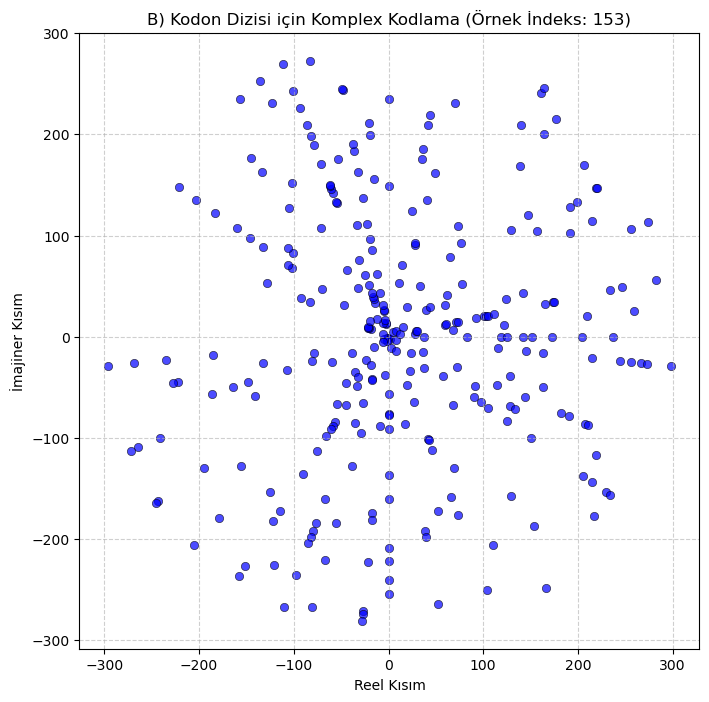

In [1]:
"""
======================================================================
KODON Dizisi için Komplex Kodlanan dosydan bir örnek
======================================================================

"""

import matplotlib.pyplot as plt
import numpy as np

# 1. .npz dosyasının yolu
npz_file_path = "cds_KODON_Compleks_L900.npz"  
data = np.load(npz_file_path)

# 2. .npz içerisindeki ilk anahtar veri dizisini al

array_key = data.files[0]
complex_matrix = data[array_key]

# 3. Veri kümesindeki satırlardan (dizilerden) rastgele birini seç
random_idx = np.random.randint(0, complex_matrix.shape[0])
complex_numbers = complex_matrix[random_idx]

# 4. Reel ve İmajiner kısımları ayır
real_parts = complex_numbers.real
imaginary_parts = complex_numbers.imag

# 5. Grafiği oluştur
plt.figure(figsize=(8, 8))
plt.scatter(
    real_parts,
    imaginary_parts,
    color="blue",
    alpha=0.7,
    edgecolors="k",
    linewidth=0.5,
)

plt.xlabel("Reel Kısım")
plt.ylabel("İmajiner Kısım")
plt.title(f"B) Kodon Dizisi için Komplex Kodlama (Örnek İndeks: {random_idx})")
plt.grid(True, linestyle="--", alpha=0.6)

# Yüksek kalitede kaydet 
plt.savefig("high_quality_plots.png", dpi=600, bbox_inches="tight")

plt.show()

## b. CDS-DNA dizilerinin KODON formunun mevcut yöntemle reel sayılara kodlanması

In [19]:
"""
=======================================================================
ASAMA 2b - CDS-DNA DIZILERININ KODON FORMUNDA MEVCUT (REEL) YONTEMLE
           KODLANMASI      (L = 900 nt = 300 kodon)

=======================================================================
"""

from pathlib import Path
import datetime
import os

import numpy as np
import pandas as pd

# ======================================================================
# AYARLAR
# ======================================================================
HEDEF_KODON = 300

GIRDI_XLSX = "cds_DNA_fasta_hazır_L900.xlsx"
CIKTI_NPZ  = "cds_KODON_Reel_L900.npz"
CIKTI_XLSX = "cds_KODON_Reel_L900_Ozet.xlsx"

LOG_DOSYA  = "boru_hatti.log"
SAYFALAR   = ["EGITIM", "TEST"]
SEQ_KOL    = "dna_seq_900"

# --- Kodon -> tam sayı (literaturdeki sıralama) -----------------------
KODONLAR = [
    "TTT","TTC","TTA","TTG","TCT","TCC","TCA","TCG","TAT","TAC","TAA","TAG","TGT","TGC","TGA","TGG",
    "CTT","CTC","CTA","CTG","CCT","CCC","CCA","CCG","CAT","CAC","CAA","CAG","CGT","CGC","CGA","CGG",
    "ATT","ATC","ATA","ATG","ACT","ACC","ACA","ACG","AAT","AAC","AAA","AAG","AGT","AGC","AGA","AGG",
    "GTT","GTC","GTA","GTG","GCT","GCC","GCA","GCG","GAT","GAC","GAA","GAG","GGT","GGC","GGA","GGG",
]
KODON_INT = {c: i for i, c in enumerate(KODONLAR)}   

ONE_HOT_URET = False


# ======================================================================
# Yardimcilar
# ======================================================================
def log_yaz(satir: str) -> None:
    damga = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with open(LOG_DOSYA, "a", encoding="utf-8") as f:
        f.write(f"[{damga}] asama2b_kodon_reel | {satir}\n")


def kodonlara_bol(seq: str):
    return [seq[i:i + 3] for i in range(0, len(seq), 3)]


def diziyi_kodla(seq: str) -> np.ndarray:
    kodonlar = kodonlara_bol(seq)
    if len(kodonlar) != HEDEF_KODON:
        raise ValueError(f"{HEDEF_KODON} kodon bekleniyordu, {len(kodonlar)} bulundu.")
    return np.fromiter((KODON_INT[c] for c in kodonlar), dtype=np.int8, count=HEDEF_KODON)


def one_hot(X: np.ndarray) -> np.ndarray:
    """(n, 300) tam sayi -> (n, 300, 64) ikili."""
    n, L = X.shape
    O = np.zeros((n, L, 64), dtype=np.uint8)
    satir, sutun = np.indices((n, L))
    O[satir, sutun, X] = 1
    return O


def sayfayi_kodla(sheet: str):
    df = pd.read_excel(GIRDI_XLSX, sheet_name=sheet)
    if SEQ_KOL not in df.columns:
        raise ValueError(f"'{sheet}' sayfasinda '{SEQ_KOL}' kolonu yok.")

    diziler = df[SEQ_KOL].astype(str).tolist()
    if {len(s) for s in diziler} != {HEDEF_KODON * 3}:
        raise ValueError(f"'{sheet}': tum diziler {HEDEF_KODON*3} nt olmalidir.")

    bilinmeyen = {c for s in diziler for c in kodonlara_bol(s)} - set(KODON_INT)
    if bilinmeyen:
        raise ValueError(f"'{sheet}': siralamada olmayan kodon(lar): {bilinmeyen}")

    X = np.stack([diziyi_kodla(s) for s in diziler]).astype(np.int8)
    return df, X



# ======================================================================
# Calıştır
# ======================================================================
def main() -> None:
    if not Path(GIRDI_XLSX).exists():
        raise FileNotFoundError(f"{GIRDI_XLSX} bulunamadi (4a ciktisi gerekli).")

    log_yaz(f"BASLANGIC | girdi={GIRDI_XLSX} | kodon={HEDEF_KODON} | "
            f"one_hot={ONE_HOT_URET}")

    paket, ozetler = {}, {}

    for sheet in SAYFALAR:
        df, X = sayfayi_kodla(sheet)
        onek = sheet.lower()

        paket[f"X_{onek}"] = X
        paket[f"y_{onek}"] = df["y"].to_numpy(dtype=np.int8)
        paket[f"acc_{onek}"] = np.array(
            df["Uniprot_Accession"].astype(str).tolist(), dtype="U32")
        if ONE_HOT_URET:
            paket[f"onehot_{onek}"] = one_hot(X)

        ozet = df[[c for c in ("Uniprot_Accession", "Gene_Name", "label", "y",
                               "alt_sinif") if c in df.columns]].copy()
        ozet["ilk10_kodon"] = ["-".join(str(v) for v in satir[:10]) for satir in X]
        ozetler[sheet] = ozet

        satir = f"{sheet}: X={X.shape} {X.dtype} | deger araligi=[{int(X.min())},{int(X.max())}] | dolgu=yok"
        print("  " + satir)
        log_yaz(satir)

    paket["L"] = np.array([HEDEF_KODON * 3])
    paket["kodon_sayisi"] = np.array([HEDEF_KODON])
    paket["etiket_sozlugu"] = np.array(["GPCR=0", "KINASE=1"])
    paket["kodlama"] = np.array(["kodon->0..63 (literatur siralamasi); dolgu=yok"])

    hizalamayi_dogrula(paket)

    np.savez_compressed(CIKTI_NPZ, **paket)
    with pd.ExcelWriter(CIKTI_XLSX, engine="openpyxl") as w:
        for sheet, ozet in ozetler.items():
            ozet.to_excel(w, sheet_name=sheet, index=False)

    print(f"Bitti. Cikti: {CIKTI_NPZ}  ve  {CIKTI_XLSX}")
    log_yaz("BITIS")


if __name__ == "__main__":
    main()

  EGITIM: X=(400, 300) int8 | deger araligi=[0,63] | dolgu=yok
  TEST: X=(200, 300) int8 | deger araligi=[0,63] | dolgu=yok
Bitti. Cikti: cds_KODON_Reel_L900.npz  ve  cds_KODON_Reel_L900_Ozet.xlsx


In [33]:

"""
======================================================================
cds_KODON_Reel_L900 CIKTISININ ILK 5 SATIRININ OKUNMASI VE YAZDIRILMASI
======================================================================
Reel kodon kodlamasi: kodon -> 0..63  (int8)
======================================================================
"""
from pathlib import Path
import numpy as np
import pandas as pd

NPZ  = "cds_KODON_Reel_L900.npz"
XLSX = "cds_KODON_Reel_L900_Ozet.xlsx"
N = 5          
K = 10         
SAYFALAR = ["egitim", "test"]


def kod_yaz(satir, k=10) -> str:
    return "-".join(str(int(v)) for v in satir[:k]) + " ..."


# ---------------------------------------------------------------------
# 1) NPZ - 
# ---------------------------------------------------------------------
d = np.load(NPZ, allow_pickle=False)

print("=" * 80)
print(f"NPZ: {NPZ}")
print("Kayitli diziler:", ", ".join(sorted(d.files)))
print("L =", int(d["L"][0]), "| kodlama:", str(d["kodlama"][0]))
print("=" * 80)

for onek in SAYFALAR:
    X   = d[f"X_{onek}"]        
    y   = d[f"y_{onek}"]        
    acc = d[f"acc_{onek}"]      
    print(f"\n[{onek.upper()}]  X={X.shape} {X.dtype} | y={y.shape} | "
          f"ilk {N} kayit (ilk {K} kod)")
    print("-" * 80)
    for i in range(min(N, len(X))):
        etiket = "GPCR" if y[i] == 0 else "KINASE"
        print(f"{acc[i]:<10} y={y[i]} ({etiket:<6}) | {kod_yaz(X[i], K)}")


# ---------------------------------------------------------------------
# 2)  XLSX -
# ---------------------------------------------------------------------
if Path(XLSX).exists():
    print("\n" + "=" * 80)
    print(f"OZET XLSX: {XLSX}")
    print("=" * 80)
    xls = pd.ExcelFile(XLSX)
    for sheet in xls.sheet_names:
        df = pd.read_excel(XLSX, sheet_name=sheet)
        print(f"\n[{sheet}] ilk {N} satir  (kolonlar: {list(df.columns)})")
        print("-" * 80)
        print(df.head(N).to_string(index=False))

NPZ: cds_KODON_Reel_L900.npz
Kayitli diziler: L, X_egitim, X_test, acc_egitim, acc_test, etiket_sozlugu, kodlama, kodon_sayisi, y_egitim, y_test
L = 900 | kodlama: kodon->0..63 (literatur siralamasi); dolgu=yok

[EGITIM]  X=(400, 300) int8 | y=(400,) | ilk 5 kayit (ilk 10 kod)
--------------------------------------------------------------------------------
O96017     y=1 (KINASE) | 35-4-31-59-7-56-48-59-52-27 ...
P41240     y=1 (KINASE) | 35-6-54-34-27-53-53-15-22-5 ...
Q01726     y=0 (GPCR  ) | 35-52-51-27-62-5-27-46-46-16 ...
Q5MAI5     y=1 (KINASE) | 35-58-43-8-58-42-2-52-43-36 ...
Q8NH57     y=0 (GPCR  ) | 35-58-4-20-40-25-36-56-48-57 ...

[TEST]  X=(200, 300) int8 | y=(200,) | ilk 5 kayit (ilk 10 kod)
--------------------------------------------------------------------------------
O60403     y=0 (GPCR  ) | 35-19-63-18-41-25-37-5-35-4 ...
Q9H341     y=0 (GPCR  ) | 35-6-49-26-8-7-17-44-20-26 ...
Q13606     y=0 (GPCR  ) | 35-58-0-38-56-46-41-9-39-3 ...
P43403     y=1 (KINASE) | 35-22

## 3) AMİNOASİT DİZİLERİNİN KODLANMASI
### a. AMİNOASİT fasta dizilerinin etiketlenip uzunlukların eşitlenmesi ve rastgele karılması.

In [22]:

"""
=======================================================================
ASAMA 3a - AMINO ASIT DIZILERININ ETIKETLENMESI, UZUNLUK ESITLEMESI VE
           SIRALANMASI      (L = 300 aa, dolgusuz)

=======================================================================
"""

from pathlib import Path
import datetime
import os
import re

import pandas as pd

# ======================================================================
# AYARLAR
# ======================================================================
GIRDI_XLSX = "3_veri_seti.xlsx"
CIKTI_XLSX = "protein_AA_hazir_L300.xlsx"
LOG_DOSYA  = "boru_hatti.log"
SAYFALAR   = ["EGITIM", "TEST"]
TOHUM      = 42

HEDEF_UZUNLUK_AA = 300
AA_KOLON = "AA_Sequence"


SIRALAMA = "hizala"
HIZALAMA_ADAYLARI = [
    "4a_dna_hazir_L900.xlsx",
    "cds_DNA_fasta_hazir_L900.xlsx",
    "cds_DNA_fasta_hazır_L900.xlsx",
]

# --- Kırpma  -------------------------------------------------------
KIRPMA_YONU = "bas"


KISA_KAYIT = "hata"

ETIKET = {"GPCR": 0, "KINASE": 1}

GECERLI_AA = set("ACDEFGHIKLMNPQRSTVWYXBZUO")


# ======================================================================
# Yardmcı
# ======================================================================
def log_yaz(satir: str) -> None:
    damga = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with open(LOG_DOSYA, "a", encoding="utf-8") as f:
        f.write(f"[{damga}] asama3a_aa_hazirla | {satir}\n")


def diziyi_temizle(x) -> str:
    if x is None:
        return ""
    s = str(x).strip()
    if s.lower() in ("", "nan", "none", "null"):
        return ""
    if s.startswith(">"):
        s = "".join(s.splitlines()[1:])
    return re.sub(r"\s+", "", s).upper()


def kirp(seq: str, L: int) -> str:
    n = len(seq)
    if KIRPMA_YONU == "bas":
        return seq[:L]
    elif KIRPMA_YONU == "son":
        return seq[n - L:]
    else:  
        bas = (n - L) // 2
        return seq[bas:bas + L]


def hizalama_sirasi(sheet: str):

    yol = next((p for p in HIZALAMA_ADAYLARI if os.path.exists(p)), None)
    if yol is None:
        return None
    ref = pd.read_excel(yol, sheet_name=sheet)
    if "Uniprot_Accession" not in ref.columns:
        return None
    return ref["Uniprot_Accession"].astype(str).tolist()


# ======================================================================
# Sayfa işleyici
# ======================================================================
def sayfayi_isle(sheet: str) -> pd.DataFrame:
    df = pd.read_excel(GIRDI_XLSX, sheet_name=sheet)

    for c in (AA_KOLON, "label", "Uniprot_Accession"):
        if c not in df.columns:
            raise ValueError(f"'{sheet}' sayfasinda '{c}' kolonu yok.")

    df = df.copy()
    df["aa_ham"] = df[AA_KOLON].apply(diziyi_temizle)

    # --- dogrulamalar --------------------------------------------------
    bos = int((df["aa_ham"] == "").sum())
    if bos:
        log_yaz(f"{sheet}: bos AA_Sequence nedeniyle {bos} kayit atildi.")
        df = df[df["aa_ham"] != ""].copy()

    gecersiz = df["aa_ham"].apply(lambda s: bool(set(s) - GECERLI_AA))
    if gecersiz.any():
        log_yaz(f"{sheet}: gecersiz AA harfi iceren {int(gecersiz.sum())} kayit atildi.")
        df = df[~gecersiz].copy()

    df["ham_uzunluk"] = df["aa_ham"].str.len()

    # --- dolgusu denetimi ------------------------------------------
    kisa = df["ham_uzunluk"] < HEDEF_UZUNLUK_AA
    if kisa.any():
        liste = df.loc[kisa, "Uniprot_Accession"].tolist()
        mesaj = (f"{sheet}: {int(kisa.sum())} kayit {HEDEF_UZUNLUK_AA} aa'dan kisa "
                 f"-> {liste[:10]}")
        log_yaz(mesaj)
        if KISA_KAYIT == "hata":
            raise ValueError(mesaj + "  | Dolgu kapali. L'yi dusurun ya da "
                                     "KISA_KAYIT='at' yapin.")
        df = df[~kisa].copy()

    # --- kırpma ---------------------------------------------------------
    df[f"aa_seq_{HEDEF_UZUNLUK_AA}"] = df["aa_ham"].apply(lambda s: kirp(s, HEDEF_UZUNLUK_AA))
    df["kirpilan_aa"] = df["ham_uzunluk"] - HEDEF_UZUNLUK_AA

    # --- etiket ----------------------------------------------------------
    bilinmeyen = set(df["label"].unique()) - set(ETIKET)
    if bilinmeyen:
        raise ValueError(f"'{sheet}' sayfasinda taninmayan etiket: {bilinmeyen}")
    df["y"] = df["label"].map(ETIKET).astype(int)

    # --- sıralama --------------------------------------------------------
    if SIRALAMA == "hizala":
        sira = hizalama_sirasi(sheet)
        if sira is not None:
            df = df.set_index("Uniprot_Accession").reindex(sira).reset_index()
            eksik = int(df[f"aa_seq_{HEDEF_UZUNLUK_AA}"].isna().sum())
            if eksik:
                raise ValueError(f"'{sheet}': 4a sirasindaki {eksik} accession AA "
                                 f"tarafinda bulunamadi. Kaynaklar tutarsiz.")
            log_yaz(f"{sheet}: siralama 4a (DNA) accession sirasina hizalandi.")
        else:
            log_yaz(f"{sheet}: 4a ciktisi yok; TOHUM={TOHUM} ile bagimsiz karildi.")
            df = df.sample(frac=1.0, random_state=TOHUM).reset_index(drop=True)
    else:
        df = df.sample(frac=1.0, random_state=TOHUM).reset_index(drop=True)

    return df


def ciktiyi_duzenle(df: pd.DataFrame) -> pd.DataFrame:
    kolonlar = [
        "Uniprot_Accession", "Entry_ID", "Gene_Name", "Protein_Name",
        "label", "y", "alt_sinif", "split",
        "Length", "ham_uzunluk", "kirpilan_aa",
        f"aa_seq_{HEDEF_UZUNLUK_AA}",
    ]
    return df[[c for c in kolonlar if c in df.columns]]


# ======================================================================
# Calıştir
# ======================================================================
def main() -> None:
    if not Path(GIRDI_XLSX).exists():
        raise FileNotFoundError(f"{GIRDI_XLSX} bulunamadi.")

    log_yaz(f"BASLANGIC | L={HEDEF_UZUNLUK_AA} aa (dolgusuz) | siralama={SIRALAMA} "
            f"| kirpma={KIRPMA_YONU} | tohum={TOHUM}")

    tablolar = {s: sayfayi_isle(s) for s in SAYFALAR}

    with pd.ExcelWriter(CIKTI_XLSX, engine="openpyxl") as w:
        for s, df in tablolar.items():
            ciktiyi_duzenle(df).to_excel(w, sheet_name=s, index=False)

    print(f"Bitti. Cikti: {CIKTI_XLSX}  (L = {HEDEF_UZUNLUK_AA} aa, dolgu yok)")
    for s, df in tablolar.items():
        seq_kol = f"aa_seq_{HEDEF_UZUNLUK_AA}"
        assert (df[seq_kol].str.len() == HEDEF_UZUNLUK_AA).all()
        ozet = (f"{s}: n={len(df)} | {df['label'].value_counts().to_dict()} | "
                f"tum diziler {HEDEF_UZUNLUK_AA} aa | dolgulu kayit=0 | "
                f"ort_kirpilan={df['kirpilan_aa'].mean():.0f} aa")
        print("  " + ozet)
        log_yaz(ozet)

    log_yaz("BITIS")


if __name__ == "__main__":
    main()

Bitti. Cikti: protein_AA_hazir_L300.xlsx  (L = 300 aa, dolgu yok)
  EGITIM: n=400 | {'KINASE': 200, 'GPCR': 200} | tum diziler 300 aa | dolgulu kayit=0 | ort_kirpilan=251 aa
  TEST: n=200 | {'GPCR': 100, 'KINASE': 100} | tum diziler 300 aa | dolgulu kayit=0 | ort_kirpilan=270 aa


In [25]:

"""
======================================================================
3a (AA) CIKTISININ ILK 5 SATIRININ YAZDIRILMASI (ERISIM NO, DIZI, LABEL/y)
======================================================================
"""
import pandas as pd

HEDEF_UZUNLUK_AA = 300
AA_XLSX = "protein_AA_hazir_L300.xlsx"
SEQ_KOL = f"aa_seq_{HEDEF_UZUNLUK_AA}"
PREVIEW_LEN = 30   

def preview(seq, n=30) -> str:
    s = str(seq)
    return s[:n] + "..." if len(s) > n else s


xls = pd.ExcelFile(AA_XLSX)
for sheet in xls.sheet_names:
    df = pd.read_excel(AA_XLSX, sheet_name=sheet)
    needed = ["Uniprot_Accession", "label", "y", SEQ_KOL]
    if not all(c in df.columns for c in needed):
        print(f"\n[{sheet}] -> kolon eksik, atlandi.")
        continue

    df["aa_preview"] = df[SEQ_KOL].apply(lambda x: preview(x, PREVIEW_LEN))
    goster = ["Uniprot_Accession", "aa_preview", "label", "y"]

    print("\n" + "=" * 80)
    print(f"[{sheet}] ILK 5 SATIR  (erisim no | dizi ilk {PREVIEW_LEN} kalinti | label | y)")
    print("=" * 80)
    print(df[goster].head(5).to_string(index=False))


[EGITIM] ILK 5 SATIR  (erisim no | dizi ilk 30 kalinti | label | y)
Uniprot_Accession                        aa_preview  label  y
           O96017 MSRESDVEAQQSHGSSACSQPHGSVTQSQG... KINASE  1
           P41240 MSAIQAAWPSGTECIAKYNFHGTAEQDLPF... KINASE  1
           Q01726 MAVQGSQRRLLGSLNSTPTAIPQLGLAANQ...   GPCR  0
           Q5MAI5 MEKYEKLAKTGEGSYGVVFKCRNKTSGQVV... KINASE  1
           Q8NH57 MESPNHTDVDPSVFFLLGIPGLEQFHLWLS...   GPCR  0

[TEST] ILK 5 SATIR  (erisim no | dizi ilk 30 kalinti | label | y)
Uniprot_Accession                        aa_preview  label  y
           O60403 MLGLNHTSMSEFILVGFSAFPHLQLMLFLL...   GPCR  0
           Q9H341 MSVQYSLSPQFMLLSNITQFSPIFYLTSFP...   GPCR  0
           Q13606 MEFTDRNYTLVTEFILLGFPTRPELQIVLF...   GPCR  0
           P43403 MPDPAAHLPFFYGSISRAEAEEHLKLAGMA... KINASE  1
           P49336 MDYDFKVKLSSERERVEDLFEYEGCKVGRG... KINASE  1


## b. AMİNOASİT dizilerinin önerilen yöntemle kompleks sayılara kodlanması

In [26]:

"""
=======================================================================
ASAMA 3b - AMINO ASIT DIZILERININ ONERILEN YONTEMLE KOMPLEKS SAYILARA
           KODLANMASI      (L = 300 aa, dolgusuz)
=======================================================================

=======================================================================
"""

from pathlib import Path
import datetime
import os

import numpy as np
import pandas as pd

# ======================================================================
# AYARLAR
# ======================================================================
HEDEF_UZUNLUK_AA = 300

GIRDI_XLSX = "protein_AA_hazir_L300.xlsx"
CIKTI_NPZ  = "AA_Compleks_L300.npz"
CIKTI_XLSX = "AA_Compleks_L300_Ozet.xlsx"
LOG_DOSYA  = "boru_hatti.log"
SAYFALAR   = ["EGITIM", "TEST"]
SEQ_KOL    = f"aa_seq_{HEDEF_UZUNLUK_AA}"

# --- Amino asit (onerilen yontem) --------------------------
VALID_AA = "ARNDCQEGHILKMFPSTWYV"                 
AA_RANK  = {aa: i for i, aa in enumerate(VALID_AA)}   # 0..19
FAZ = {aa: np.pi * (i + 1) / 10 for i, aa in enumerate(VALID_AA)}  

# --- Konum agirligi taban noktasi -------------------------------------

KONUM_BASLANGIC = 1


OLCEKLEME = "yok"


STANDART_DISI = "onerilen"
TOHUM = 42

OZELLIK_DUZLEMLERI = True


# ======================================================================
# Yardimcılar
# ======================================================================
def log_yaz(satir: str) -> None:
    damga = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with open(LOG_DOSYA, "a", encoding="utf-8") as f:
        f.write(f"[{damga}] asama3b_aa_kompleks | {satir}\n")


def diziyi_kodla(seq: str, a: np.ndarray, rng) -> tuple:
    
    if len(seq) != HEDEF_UZUNLUK_AA:
        raise ValueError(f"{HEDEF_UZUNLUK_AA} aa bekleniyordu, {len(seq)} bulundu.")
    faz = np.empty(HEDEF_UZUNLUK_AA, dtype=np.float64)
    gecerli = np.ones(HEDEF_UZUNLUK_AA, dtype=bool)   
    disi = 0
    for i, aa in enumerate(seq):
        if aa in FAZ:
            faz[i] = FAZ[aa]
        elif aa == "X" and STANDART_DISI == "onerilen":
            faz[i] = FAZ[VALID_AA[rng.integers(len(VALID_AA))]]   
            disi += 1
        else:
            gecerli[i] = False   
            disi += 1
    z = np.where(gecerli, a * np.exp(1j * faz), 0).astype(np.complex64)
    return z, disi


def sayfayi_kodla(sheet: str, rng):
    df = pd.read_excel(GIRDI_XLSX, sheet_name=sheet)
    if SEQ_KOL not in df.columns:
        raise ValueError(f"'{sheet}' sayfasinda '{SEQ_KOL}' kolonu yok.")

    diziler = df[SEQ_KOL].astype(str).tolist()
    if {len(s) for s in diziler} != {HEDEF_UZUNLUK_AA}:
        raise ValueError(f"'{sheet}': tum diziler {HEDEF_UZUNLUK_AA} aa olmalidir.")

    a = np.arange(HEDEF_UZUNLUK_AA, dtype=np.float64) + KONUM_BASLANGIC
    if OLCEKLEME == "bol_N":
        a = a / HEDEF_UZUNLUK_AA
    elif OLCEKLEME != "yok":
        raise ValueError("OLCEKLEME 'yok' veya 'bol_N' olmalidir.")

    satirlar, toplam_disi = [], 0
    for s in diziler:
        z, disi = diziyi_kodla(s, a, rng)
        satirlar.append(z)
        toplam_disi += disi
    X = np.stack(satirlar).astype(np.complex64)
    if toplam_disi:
        log_yaz(f"{sheet}: {toplam_disi} standart-disi kalinti "
                f"(strateji={STANDART_DISI}).")
    return df, X


def ozellik_duzlemleri(X: np.ndarray):
    return (X.real.astype(np.float32),
            X.imag.astype(np.float32),
            np.abs(X).astype(np.float32),
            np.degrees(np.angle(X)).astype(np.float32))


# ======================================================================
# Calistir
# ======================================================================
def main() -> None:
    if not Path(GIRDI_XLSX).exists():
        raise FileNotFoundError(f"{GIRDI_XLSX} bulunamadi (3a ciktisi gerekli).")

    log_yaz(f"BASLANGIC | girdi={GIRDI_XLSX} | L={HEDEF_UZUNLUK_AA} | "
            f"konum_baslangic={KONUM_BASLANGIC} | olcekleme={OLCEKLEME} | "
            f"standart_disi={STANDART_DISI}")
    rng = np.random.default_rng(TOHUM)

    paket, ozetler = {}, {}

    for sheet in SAYFALAR:
        df, X = sayfayi_kodla(sheet, rng)
        onek = sheet.lower()

        paket[f"X_{onek}"] = X
        paket[f"y_{onek}"] = df["y"].to_numpy(dtype=np.int8)
        paket[f"acc_{onek}"] = np.array(
            df["Uniprot_Accession"].astype(str).tolist(), dtype="U32")

        if OZELLIK_DUZLEMLERI:
            reel, imag, mod, faz = ozellik_duzlemleri(X)
            paket[f"reel_{onek}"] = reel
            paket[f"imag_{onek}"] = imag
            paket[f"mod_{onek}"] = mod
            paket[f"faz_{onek}"] = faz

        ozet = df[[c for c in ("Uniprot_Accession", "Gene_Name", "label", "y",
                               "alt_sinif") if c in df.columns]].copy()
        ozet["ilk5_kompleks"] = [
            "; ".join(f"{z.real:+.4f}{z.imag:+.4f}j" for z in satir[:5]) for satir in X
        ]
        ozetler[sheet] = ozet

        satir = (f"{sheet}: X={X.shape} {X.dtype} | ort|z|={float(np.abs(X).mean()):.4f} "
                 f"| dolgu=yok")
        print("  " + satir)
        log_yaz(satir)

    paket["L"] = np.array([HEDEF_UZUNLUK_AA])
    paket["etiket_sozlugu"] = np.array(["GPCR=0", "KINASE=1"])
    paket["kodlama"] = np.array([f"z=a*exp(j*pi*(AA_rank+1)/10); VALID_AA={VALID_AA}; "
                                 f"a=i+{KONUM_BASLANGIC}; olcekleme={OLCEKLEME}; dolgu=yok"])

    np.savez_compressed(CIKTI_NPZ, **paket)
    with pd.ExcelWriter(CIKTI_XLSX, engine="openpyxl") as w:
        for sheet, ozet in ozetler.items():
            ozet.to_excel(w, sheet_name=sheet, index=False)

    print(f"Bitti. Cikti: {CIKTI_NPZ}  ve  {CIKTI_XLSX}")
    log_yaz("BITIS")


# ----------------------------------------------------------------------
# Kullanim:

# ----------------------------------------------------------------------

if __name__ == "__main__":
    main()

  EGITIM: X=(400, 300) complex64 | ort|z|=150.5000 | dolgu=yok
  TEST: X=(200, 300) complex64 | ort|z|=150.5000 | dolgu=yok
Bitti. Cikti: AA_Compleks_L300.npz  ve  AA_Compleks_L300_Ozet.xlsx


In [28]:

"""
======================================================================
(AA KOMPLEKS) CIKTISININ ILK 5 SATIRININ OKUNMASI VE YAZDIRILMASI
======================================================================

"""
from pathlib import Path
import numpy as np
import pandas as pd

NPZ  = "AA_Compleks_L300.npz"
XLSX = "AA_Compleks_L300_Ozet.xlsx"
N = 5         
K = 5         
SAYFALAR = ["egitim", "test"]


def kompleks_yaz(z_satiri, k=5) -> str:
    return "; ".join(f"{z.real:+.5f}{z.imag:+.5f}i" for z in z_satiri[:k]) + " ..."


# ---------------------------------------------------------------------
# 1) NPZ - 
# ---------------------------------------------------------------------
d = np.load(NPZ, allow_pickle=False)

print("=" * 80)
print(f"NPZ: {NPZ}")
print("Kayitli diziler:", ", ".join(sorted(d.files)))
print("L =", int(d["L"][0]), "| kodlama:", str(d["kodlama"][0]))
print("=" * 80)

for onek in SAYFALAR:
    X   = d[f"X_{onek}"]        # (n, 300) complex64
    y   = d[f"y_{onek}"]        # (n,)     int8
    acc = d[f"acc_{onek}"]      # (n,)     str
    print(f"\n[{onek.upper()}]  X={X.shape} {X.dtype} | "
          f"ilk {N} kayit (ilk {K} kompleks deger)")
    print("-" * 80)
    for i in range(min(N, len(X))):
        etiket = "GPCR" if y[i] == 0 else "KINASE"
        print(f"{acc[i]:<10} y={y[i]} ({etiket:<6}) | {kompleks_yaz(X[i], K)}")


# ---------------------------------------------------------------------
# 2) OZET XLSX - 
# ---------------------------------------------------------------------
if Path(XLSX).exists():
    print("\n" + "=" * 80)
    print(f"OZET XLSX: {XLSX}")
    print("=" * 80)
    xls = pd.ExcelFile(XLSX)
    for sheet in xls.sheet_names:
        df = pd.read_excel(XLSX, sheet_name=sheet)
        print(f"\n[{sheet}] ilk {N} satir  (kolonlar: {list(df.columns)})")
        print("-" * 80)
        print(df.head(N).to_string(index=False))

NPZ: AA_Compleks_L300.npz
Kayitli diziler: L, X_egitim, X_test, acc_egitim, acc_test, etiket_sozlugu, faz_egitim, faz_test, imag_egitim, imag_test, kodlama, mod_egitim, mod_test, reel_egitim, reel_test, y_egitim, y_test
L = 300 | kodlama: z=a*exp(j*pi*(AA_rank+1)/10); VALID_AA=ARNDCQEGHILKMFPSTWYV; a=i+1; olcekleme=yok; dolgu=yok

[EGITIM]  X=(400, 300) complex64 | ilk 5 kayit (ilk 5 kompleks deger)
--------------------------------------------------------------------------------
O96017     y=1 (KINASE) | -0.58779-0.80902i; +0.61803-1.90211i; +2.42705+1.76336i; -2.35114+3.23607i; +1.54508-4.75528i ...
P41240     y=1 (KINASE) | -0.58779-0.80902i; +0.61803-1.90211i; +2.85317+0.92705i; -4.00000+0.00000i; -1.54508+4.75528i ...
Q01726     y=0 (GPCR  ) | -0.58779-0.80902i; +1.90211+0.61803i; +3.00000-0.00000i; -1.23607+3.80423i; -4.04508+2.93893i ...
Q5MAI5     y=1 (KINASE) | -0.58779-0.80902i; -1.17557+1.61803i; -2.42705-1.76336i; +3.80423-1.23607i; -2.93893+4.04508i ...
Q8NH57     y=0 (GPCR

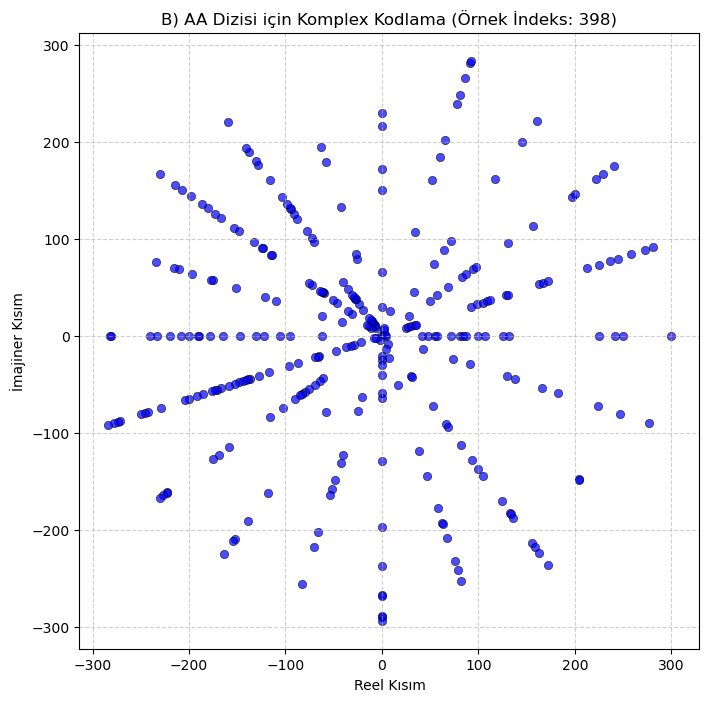

In [3]:
"""
======================================================================
AA Dizisi için Komplex Kodlanan dosaydan bir örnek
======================================================================

"""

import matplotlib.pyplot as plt
import numpy as np

# 1. .npz dosyasının yolu
npz_file_path = "AA_Compleks_L300.npz"  # Dosya yolu
data = np.load(npz_file_path)

# 2. .npz içerisindeki ilk anahtar veri dizisini al
array_key = data.files[0]
complex_matrix = data[array_key]

# 3. Veri kümesindeki satırlardan (dizilerden) rastgele birini seç
random_idx = np.random.randint(0, complex_matrix.shape[0])
complex_numbers = complex_matrix[random_idx]

# 4. Reel ve İmajiner kısımları ayır
real_parts = complex_numbers.real
imaginary_parts = complex_numbers.imag

# 5. Grafiği oluştur
plt.figure(figsize=(8, 8))
plt.scatter(
    real_parts,
    imaginary_parts,
    color="blue",
    alpha=0.7,
    edgecolors="k",
    linewidth=0.5,
)

plt.xlabel("Reel Kısım")
plt.ylabel("İmajiner Kısım")
plt.title(f"B) AA Dizisi için Komplex Kodlama (Örnek İndeks: {random_idx})")
plt.grid(True, linestyle="--", alpha=0.6)

# Yüksek kalitede kaydet 
plt.savefig("high_quality_plots.png", dpi=600, bbox_inches="tight")

plt.show()

## c. AMİNOASİT dizilerinin karşılaştırma için mevcut yöntemle reel değerli tam sayılara kodlanması

In [29]:

"""
=======================================================================
ASAMA 3c - AMINO ASIT DIZILERININ KARSILASTIRMA ICIN MEVCUT (REEL)
           YONTEMLE TAM SAYILARA KODLANMASI      (L = 300 aa, dolgusuz)
=======================================================================

"""

from pathlib import Path
import datetime
import os

import numpy as np
import pandas as pd

# ======================================================================
# AYARLAR
# ======================================================================
HEDEF_UZUNLUK_AA = 300

GIRDI_XLSX = "protein_AA_hazir_L300.xlsx"
CIKTI_NPZ  = "AA_Reel_L300.npz"
CIKTI_XLSX = "AA_Reel_L300_Ozet.xlsx"
KOMPLEKS_NPZ = "AA_Compleks_L300.npz"          
LOG_DOSYA  = "boru_hatti.log"
SAYFALAR   = ["EGITIM", "TEST"]
SEQ_KOL    = f"aa_seq_{HEDEF_UZUNLUK_AA}"

# --- Amino asit -> tam sayı (literaturdeki yöntem,) -----------
AMINO_ACIDS = "FLSYCWPHQRIMTNKVADEG"
AMINO_INT = {aa: i for i, aa in enumerate(AMINO_ACIDS, start=1)}   
BILINMEYEN = 0                                                     


ONE_HOT_URET = False


# ======================================================================
# Yardimcı
# ======================================================================
def log_yaz(satir: str) -> None:
    damga = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with open(LOG_DOSYA, "a", encoding="utf-8") as f:
        f.write(f"[{damga}] asama3c_aa_reel | {satir}\n")


def diziyi_kodla(seq: str) -> np.ndarray:
    if len(seq) != HEDEF_UZUNLUK_AA:
        raise ValueError(f"{HEDEF_UZUNLUK_AA} aa bekleniyordu, {len(seq)} bulundu.")
    return np.fromiter((AMINO_INT.get(aa, BILINMEYEN) for aa in seq),
                       dtype=np.int8, count=HEDEF_UZUNLUK_AA)


def one_hot(X: np.ndarray) -> np.ndarray:
    """(n, 300) tam sayi (0..20) -> (n, 300, 21) ikili."""
    n, L = X.shape
    O = np.zeros((n, L, 21), dtype=np.uint8)
    satir, sutun = np.indices((n, L))
    O[satir, sutun, X] = 1
    return O


def sayfayi_kodla(sheet: str):
    df = pd.read_excel(GIRDI_XLSX, sheet_name=sheet)
    if SEQ_KOL not in df.columns:
        raise ValueError(f"'{sheet}' sayfasinda '{SEQ_KOL}' kolonu yok.")

    diziler = df[SEQ_KOL].astype(str).tolist()
    if {len(s) for s in diziler} != {HEDEF_UZUNLUK_AA}:
        raise ValueError(f"'{sheet}': tum diziler {HEDEF_UZUNLUK_AA} aa olmalidir.")

    X = np.stack([diziyi_kodla(s) for s in diziler]).astype(np.int8)

    disi = int((X == BILINMEYEN).sum())
    if disi:
        log_yaz(f"{sheet}: {disi} standart-disi kalinti 0'a atandi.")
    return df, X


def hizalamayi_dogrula(paket: dict) -> None:
    if not Path(KOMPLEKS_NPZ).exists():
        log_yaz("3b ciktisi bulunamadi, hizalama dogrulamasi atlandi.")
        return
    k = np.load(KOMPLEKS_NPZ, allow_pickle=False)
    for sheet in SAYFALAR:
        onek = sheet.lower()
        for anahtar in (f"acc_{onek}", f"y_{onek}"):
            if not np.array_equal(k[anahtar], paket[anahtar]):
                raise AssertionError(f"3b ile 3c arasinda '{anahtar}' uyusmuyor.")
    print("  Hizalama dogrulandi: 3b ve 3c ayni kayitlari ayni sirayla kodluyor.")
    log_yaz("Hizalama dogrulandi (3b == 3c: accession, etiket).")


# ======================================================================
# Calistır
# ======================================================================
def main() -> None:
    if not Path(GIRDI_XLSX).exists():
        raise FileNotFoundError(f"{GIRDI_XLSX} bulunamadi (3a ciktisi gerekli).")

    log_yaz(f"BASLANGIC | girdi={GIRDI_XLSX} | L={HEDEF_UZUNLUK_AA} | "
            f"one_hot={ONE_HOT_URET}")

    paket, ozetler = {}, {}

    for sheet in SAYFALAR:
        df, X = sayfayi_kodla(sheet)
        onek = sheet.lower()

        paket[f"X_{onek}"] = X
        paket[f"y_{onek}"] = df["y"].to_numpy(dtype=np.int8)
        paket[f"acc_{onek}"] = np.array(
            df["Uniprot_Accession"].astype(str).tolist(), dtype="U32")
        if ONE_HOT_URET:
            paket[f"onehot_{onek}"] = one_hot(X)

        ozet = df[[c for c in ("Uniprot_Accession", "Gene_Name", "label", "y",
                               "alt_sinif") if c in df.columns]].copy()
        ozet["ilk15_kod"] = ["-".join(str(v) for v in satir[:15]) for satir in X]
        ozetler[sheet] = ozet

        satir = (f"{sheet}: X={X.shape} {X.dtype} | "
                 f"deger araligi=[{int(X.min())},{int(X.max())}] | dolgu=yok")
        print("  " + satir)
        log_yaz(satir)

    paket["L"] = np.array([HEDEF_UZUNLUK_AA])
    paket["etiket_sozlugu"] = np.array(["GPCR=0", "KINASE=1"])
    paket["kodlama"] = np.array([f"AA->1..20 ({AMINO_ACIDS}); bilinmeyen=0; dolgu=yok"])

    hizalamayi_dogrula(paket)

    np.savez_compressed(CIKTI_NPZ, **paket)
    with pd.ExcelWriter(CIKTI_XLSX, engine="openpyxl") as w:
        for sheet, ozet in ozetler.items():
            ozet.to_excel(w, sheet_name=sheet, index=False)

    print(f"Bitti. Cikti: {CIKTI_NPZ}  ve  {CIKTI_XLSX}")
    log_yaz("BITIS")


# ----------------------------------------------------------------------
# Kullanim:
# ----------------------------------------------------------------------

if __name__ == "__main__":
    main()

  EGITIM: X=(400, 300) int8 | deger araligi=[1,20] | dolgu=yok
  TEST: X=(200, 300) int8 | deger araligi=[1,20] | dolgu=yok
  Hizalama dogrulandi: 3b ve 3c ayni kayitlari ayni sirayla kodluyor.
Bitti. Cikti: AA_Reel_L300.npz  ve  AA_Reel_L300_Ozet.xlsx


In [30]:

"""
======================================================================
3c (AA REEL) CIKTISININ ILK 5 SATIRININ OKUNMASI VE YAZDIRILMASI

======================================================================
"""
from pathlib import Path
import numpy as np
import pandas as pd

NPZ  = "AA_Reel_L300.npz"
XLSX = "AA_Reel_L300_Ozet.xlsx"
N = 5          
K = 15         
SAYFALAR = ["egitim", "test"]


def kod_yaz(satir, k=15) -> str:
    return "-".join(str(int(v)) for v in satir[:k]) + " ..."


# ---------------------------------------------------------------------
# 1) NPZ - 
# ---------------------------------------------------------------------
d = np.load(NPZ, allow_pickle=False)

print("=" * 80)
print(f"NPZ: {NPZ}")
print("Kayitli diziler:", ", ".join(sorted(d.files)))
print("L =", int(d["L"][0]), "| kodlama:", str(d["kodlama"][0]))
print("=" * 80)

for onek in SAYFALAR:
    X   = d[f"X_{onek}"]        #
    y   = d[f"y_{onek}"]        # 
    acc = d[f"acc_{onek}"]      # 
    print(f"\n[{onek.upper()}]  X={X.shape} {X.dtype} | ilk {N} kayit (ilk {K} kod)")
    print("-" * 80)
    for i in range(min(N, len(X))):
        etiket = "GPCR" if y[i] == 0 else "KINASE"
        print(f"{acc[i]:<10} y={y[i]} ({etiket:<6}) | {kod_yaz(X[i], K)}")


# ---------------------------------------------------------------------
# 2) OZET XLSX - 
# ---------------------------------------------------------------------
if Path(XLSX).exists():
    print("\n" + "=" * 80)
    print(f"OZET XLSX: {XLSX}")
    print("=" * 80)
    xls = pd.ExcelFile(XLSX)
    for sheet in xls.sheet_names:
        df = pd.read_excel(XLSX, sheet_name=sheet)
        print(f"\n[{sheet}] ilk {N} satir  (kolonlar: {list(df.columns)})")
        print("-" * 80)
        print(df.head(N).to_string(index=False))

NPZ: AA_Reel_L300.npz
Kayitli diziler: L, X_egitim, X_test, acc_egitim, acc_test, etiket_sozlugu, kodlama, y_egitim, y_test
L = 300 | kodlama: AA->1..20 (FLSYCWPHQRIMTNKVADEG); bilinmeyen=0; dolgu=yok

[EGITIM]  X=(400, 300) int8 | ilk 5 kayit (ilk 15 kod)
--------------------------------------------------------------------------------
O96017     y=1 (KINASE) | 12-3-10-19-3-18-16-19-17-9-9-3-8-20-3 ...
P41240     y=1 (KINASE) | 12-3-17-11-9-17-17-6-7-3-20-13-19-5-11 ...
Q01726     y=0 (GPCR  ) | 12-17-16-9-20-3-9-10-10-2-2-20-3-2-14 ...
Q5MAI5     y=1 (KINASE) | 12-19-15-4-19-15-2-17-15-13-20-19-20-3-4 ...
Q8NH57     y=0 (GPCR  ) | 12-19-3-7-14-8-13-18-16-18-7-3-16-1-1 ...

[TEST]  X=(200, 300) int8 | ilk 5 kayit (ilk 15 kod)
--------------------------------------------------------------------------------
O60403     y=0 (GPCR  ) | 12-2-20-2-14-8-13-3-12-3-19-1-11-2-16 ...
Q9H341     y=0 (GPCR  ) | 12-3-16-9-4-3-2-3-7-9-1-12-2-2-3 ...
Q13606     y=0 (GPCR  ) | 12-19-1-13-18-10-14-4-13-2